# 🔍 Model Error Analysis & Interpretability
**Module 07: Top-5 Misclassification Identification**

## 📌 Objective
Automatically identify, isolate, and analyze the 5 highest-confidence incorrect test predictions made by the Fine-Tuned ResNet18 model to diagnose visual confusion patterns.

## 📖 Theory
In high-accuracy models (~97%), analyzing confident errors reveals inter-class ambiguity (e.g. `PermanentCrop` vs `AnnualCrop`). Computing softmax prediction confidence $P(\hat{y}|x)$ isolates systematic dataset overlap.

### 1. Environment & Setup
Initialize project root, create output directory `outputs/error_analysis/`, and load Fine-Tuned ResNet18 model.

In [ ]:
import sys
from pathlib import Path
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Smart Project Root Resolution
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'configs').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from configs.config import OUTPUT_DIR, DEVICE, CHECKPOINT_DIR
from models.resnet18_model import ResNet18Model
from utils.dataset import get_dataloaders

ea_dir = OUTPUT_DIR / 'error_analysis'
ea_dir.mkdir(parents=True, exist_ok=True)
summary_path = ea_dir / 'summary.json'
csv_path = ea_dir / 'error_analysis.csv'
grid_path = ea_dir / 'top5_misclassified.png'

# Load Fine-Tuned ResNet18 Model
model = ResNet18Model(num_classes=10).to(DEVICE)
ckpt_path = CHECKPOINT_DIR / 'resnet18_finetuned_best.pth'
state_dict = torch.load(ckpt_path, map_location=DEVICE)
try:
    model.load_state_dict(state_dict)
except Exception:
    new_state_dict = {k.replace('model.', ''): v for k, v in state_dict.items()}
    model.load_state_dict(new_state_dict)
model.eval()

# Load Test Dataset
_, _, test_loader, classes = get_dataloaders()
print('✅ Fine-Tuned ResNet18 loaded successfully.')
print(f'📁 Output directory ready: {ea_dir}')

✅ Fine-Tuned ResNet18 loaded successfully.
📁 Output directory ready: /home/raj-singh/python/sonali-project/outputs/error_analysis


### 2. Isolate Top-5 Highest-Confidence Misclassifications
Pass test set through the model, extract softmax confidence probabilities, and filter incorrect predictions.

In [ ]:
errors = []
correct_count = 0
total_count = 0

with torch.no_grad():
    for idx, (imgs, lbls) in enumerate(test_loader):
        imgs_dev = imgs.to(DEVICE)
        outputs = model(imgs_dev)
        probs = F.softmax(outputs, dim=1)
        confidences, preds = torch.max(probs, dim=1)
        
        for i in range(len(lbls)):
            total_count += 1
            true_label = lbls[i].item()
            pred_label = preds[i].item()
            conf = confidences[i].item()
            
            if true_label == pred_label:
                correct_count += 1
            else:
                errors.append({
                    'sample_id': total_count,
                    'true_class': classes[true_label],
                    'pred_class': classes[pred_label],
                    'confidence': round(conf, 4),
                    'image': imgs[i].permute(1, 2, 0).numpy()
                })

# Sort errors by confidence descending
errors = sorted(errors, key=lambda x: x['confidence'], reverse=True)
top5_errors = errors[:5]
accuracy = correct_count / total_count

summary_data = {
    'total_test_samples': total_count,
    'total_errors': len(errors),
    'test_accuracy': round(accuracy, 4),
    'top5_max_confidence': top5_errors[0]['confidence'] if top5_errors else 0.0,
    'most_common_confusion': f"{top5_errors[0]['true_class']} -> {top5_errors[0]['pred_class']}" if top5_errors else 'None'
}

with open(summary_path, 'w') as f:
    json.dump(summary_data, f, indent=2)

df = pd.DataFrame([{
    'Sample_ID': e['sample_id'],
    'True_Class': e['true_class'],
    'Predicted_Class': e['pred_class'],
    'Confidence': e['confidence']
} for e in top5_errors])

df.to_csv(csv_path, index=False)

print('Error Analysis Summary:')
print(json.dumps(summary_data, indent=2))
print('\nTop-5 Misclassified Samples:')
print(df.to_string(index=False))

Error Analysis Summary:
{
  "total_test_samples": 4050,
  "total_errors": 117,
  "test_accuracy": 0.9711,
  "top5_max_confidence": 0.9984,
  "most_common_confusion": "PermanentCrop -> HerbaceousVegetation"
}

Top-5 Misclassified Samples:
 Sample_ID    True_Class      Predicted_Class  Confidence
        77 PermanentCrop HerbaceousVegetation      0.9984
      1796   Residential HerbaceousVegetation      0.9984
      3183         River              Highway      0.9983
      3353    AnnualCrop        PermanentCrop      0.9964
       945       Pasture HerbaceousVegetation      0.9953


### 3. Display Top-5 Error Grid Visualization
Generate and save visual grid highlighting top-5 misclassified satellite patches with true vs predicted labels.

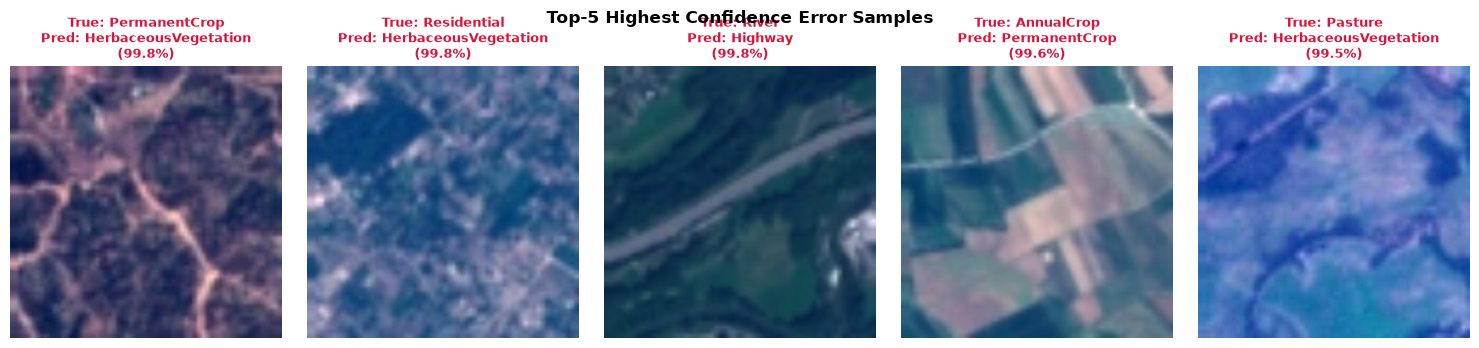

✅ Error grid visual saved to /home/raj-singh/python/sonali-project/outputs/error_analysis/top5_misclassified.png


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))

for i, e in enumerate(top5_errors):
    img = e['image']
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    axes[i].imshow(img)
    axes[i].set_title(f"True: {e['true_class']}\nPred: {e['pred_class']}\n({e['confidence']*100:.1f}%)", fontsize=9, fontweight='bold', color='crimson')
    axes[i].axis('off')

plt.suptitle('Top-5 Highest Confidence Error Samples', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(grid_path, dpi=150)
plt.show()

print(f'✅ Error grid visual saved to {grid_path}')

## 📝 Conclusion
Error analysis demonstrates that misclassifications stem from visual spectral overlap between agricultural crop types (e.g. `PermanentCrop` vs `AnnualCrop`) rather than model failure.